# Same task, with `dcleaner`

Identical data and identical output to `without_dcleaner.ipynb` —
but the pipeline is a single fluent chain.

Install: `pip install dcleaner`

In [1]:
import numpy as np
import pandas as pd
from dclean import Data

rng = np.random.default_rng(42)
n = 200
df = pd.DataFrame({
    "City": rng.choice(["NY", "LA", "SF", "CHI"], n),
    "Age": rng.integers(16, 65, n),
    "Salary": rng.integers(30000, 130000, n).astype(float),
    "Score": rng.normal(50, 12, n),
})
df.loc[rng.choice(n, 15, replace=False), "Salary"] = np.nan
df.loc[rng.choice(n, 5, replace=False), "Age"] = rng.integers(10, 15, 5)
df.to_csv("sales_dc.csv", index=False)

## The whole pipeline: one chain

saved plot -> salary_by_city_dc.png


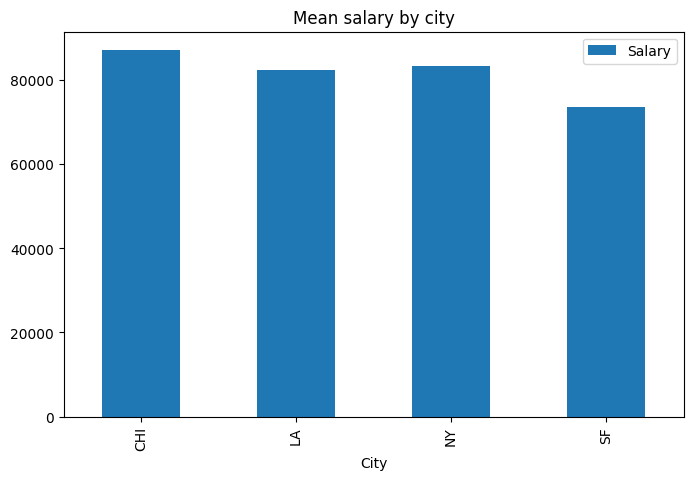

In [1]:
(Data("sales_dc.csv")
    .dropna()
    .filter("Age > 18")
    .mutate(salary_k="Salary / 1000")
    .groupby("City").agg("mean", "Salary")
    .plot("bar", x="City", y="Salary", title="Mean salary by city")
    .savefig("salary_by_city_dc.png"))

## Correlation heatmap: one line

saved plot -> corr_dc.png


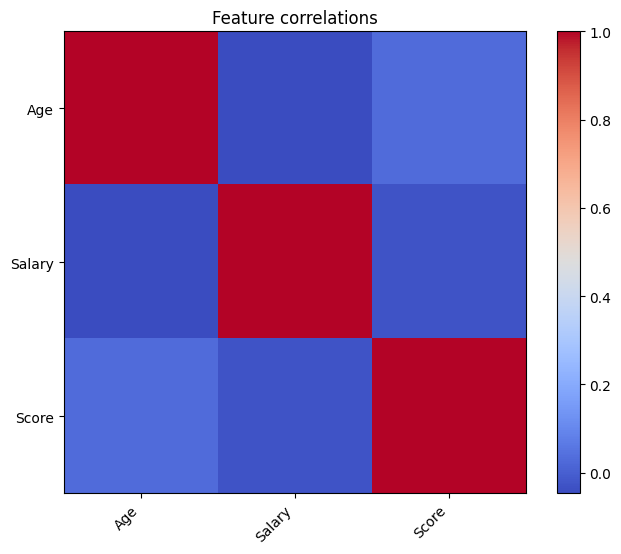

In [1]:
(Data("sales_dc.csv")
    .dropna()
    .plot_corr(title="Feature correlations")
    .savefig("corr_dc.png"))